# Insulin4RL - Real-Time ICU Insulin Management using Offline Reinforcement Learning

<span style="font-size: 20px;"><b>Welcome to Insulin4RL!</b> </span>

<span style="font-size: 16px;"> The <b>Insulin4RL</b> dataset is a curated collection derived from MIMIC-IV, specifically designed for <b>Offline Reinforcement Learning (ORL)</b>. The dataset is distinct in that it chooses to incorporate <b>naturally irregular intervals</b> between states, a key aspect of clinical care.

---
<span style="font-size: 16px;"> This notebook provides a comprehensive demonstration of the dataset's workflows to get you started. The data can be accessed through two primary approaches:</span>

- <span style="font-size: 14px;">Loaded as `Tensors` containing <i>(state, action, reward, done, next_state, info)</i> tuples</span>

- <span style="font-size: 14px;">Loaded as a `DataFrame` for manual inspection / exploratory data analysis.</span>

---

<span style="font-size: 16px;">The following cell imports all relevant packages for this notebook. If not done already, make sure you have installed the relative requirements in the `pixi.toml` file, which is best done using the `pixi` package manager (https://pixi.prefix.dev/latest/).</span>

In [1]:
#####################
# IMPORT STATEMENTS #
#####################
import polars as pl
import torch
import torch.nn.functional as F
from torcheval.metrics import BinaryAUROC
import numpy as np
from tqdm import tqdm
import copy
import yaml
from dataclasses import fields
from IPython.display import JSON, Markdown, display

from notebook_utils.tools import update_plots, Batch, DataLoader
from notebook_utils.models import CNNLSTMModel
from notebook_utils.datasets import ExampleDataset, CloningDataset, FQEDataset

def console_print(x):
    if isinstance(x, str):
        display(Markdown(x))
    else:
        display(x)

#####################
# CONFIG STATEMENTS #
#####################
pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_width_chars(5000)

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False, linewidth=100)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

## Inspecting the `DataFrame` and `metadata`

The following cell demonstrates the `all_data.parquet` file, which includes all the data contained within the various `safetensors` files. The only difference is that all input data here is unnormalised, whereas the `safetensors` states are already log-normalised for convenience. 

**N.B.** The input data is a structured sequence of 400 discrete medical events. Each event is structured as a tuple of _(feature, time, value)_. The first three events are always the patient's age, gender (0=male, 1=female), and weight. The rest of the events are ordered from old to new, followed by right-padding if necessary. See the PhysioNet description for full details.

<span>**Columns**<span>
- **Unique identifiers**
  - `data_segment`: Whether the data is train/val/test.
  - `subject_id`: The unique MIMIC-IV subject_id for this patient.
  - `label_id`: The unique ID for this labelled decision.
  - `label_id_next`: The unique ID for the next labelled decision (if it exists).
  - `episode_num`: The unique ID for this trajectory.
  - `step_num`: The step number for this labelled transition, starting from 1.
  - `labeltime`: The MIMIC-IV timestamp for this labelled decision (rounded to the nearest 5 minutes).
  - `labeltime_next`: The MIMIC-IV timestamp for the next labelled decision (if it exists).
- **Temporal context**
  - `steps_per_episode`: The number of labelled decisions for this trajectory.
  - `steps_remaining`: The number of future labelled decisions remaining in this trajectory.
  - `minutes_remaining`: The minutes remaining until the final labelled decision in this trajectory.
  - `is_done`: Whether this decision is the final decision of the trajectory.
- **Physiological information**
  - `current_bm`: The current blood glucose that has triggered this decision.
  - `prev_bm`: The blood glucose at the last decision (if it exists).
  - `next_bm`: The blood glucose at the next decision (if it exists).
  - `time_since_prev_bm`: The time (in minutes) since the last decision (if it exists).
  - `time_until_next_bm`: The time (in minutes) until the next decision (if it exists).
- **Insulin information**
  - `insulin_changetime`: The MIMIC-IV timestamp for any changes made to the insulin (rounded to the nearest 5 minutes).
  - `insulin_old_rate`: The insulin infusion rate before the labelled decision.
  - `insulin_new_rate`: The insulin infusion rate after the labelled decision.
  - `insulin_maintain`: (Binary) Whether the insulin was left unchanged. 1=no change, 0=change.
  - `insulin_change`: (Binary) Whether the insulin was changed but _not stopped_. 1=change, 0=no change.
  - `insulin_stop`: (Binary) Whether the insulin was _stopped_. 1=stop, 0=not stopped.
  - `insulin_delta_change`: The change in insulin rate (insulin_new_rate - insulin_old_rate).
  - _(The above four actions are repeated using \_prev and \_next suffixes, for the previous and next labelled decisions.)_
- **Mortality outcomes**
  - `1/3/7/14/28-day-alive`: Whether the patient is alive (1) or dead (0) _x_ days into the future, relative to this decision.
  - `1/3/7/14/28-day-alive-final`: Whether the patient is alive (1) or dead (0) _x_ days into the future, relative to the final state of the trajectory.
- **Input states**
  - `feature`: The integer feature code of the past medical event.
  - `time`: The timestamp of the past medical event, in minutes relative to the current labelled decision (i.e., $t=0$ is now, and $t=60$ is 60 minutes ago.
  - `value`: The value of the past medical event.
  - _(The above inputs are repeated using \_next suffixes, for the input state of the next labelled decision.)_

In [2]:
# Scan the .parquet file to keep it out-of-memory.
all_data = pl.scan_parquet('./data/insulin4rl/all_data.parquet')
all_data.head().collect()

data_segment,subject_id,label_id,label_id_next,episode_num,step_num,labeltime,labeltime_next,steps_per_episode,steps_remaining,minutes_remaining,is_done,current_bm,prev_bm,next_bm,time_since_prev_bm,time_until_next_bm,insulin_changetime,insulin_old_rate,insulin_new_rate,insulin_maintain,insulin_change,insulin_stop,insulin_delta_change,insulin_maintain_prev,insulin_change_prev,insulin_stop_prev,insulin_delta_change_prev,insulin_maintain_next,insulin_change_next,insulin_stop_next,insulin_delta_change_next,1-day-alive,3-day-alive,7-day-alive,14-day-alive,28-day-alive,1-day-alive-final,3-day-alive-final,7-day-alive-final,14-day-alive-final,28-day-alive-final,feature,time,value,feature_next,time_next,value_next
str,i64,u32,u32,u32,u32,datetime[μs],datetime[μs],u32,u32,i64,i32,f64,f64,f64,i64,i64,datetime[μs],f64,f64,i32,i32,i32,f64,i32,i32,i32,f64,i32,i32,i32,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,list[i16],list[i16],list[f64],list[i16],list[i16],list[f64]
"""train""",10518799,19078,19079,688,1,2169-10-21 21:00:00,2169-10-21 21:45:00,13,12,1500,0,8.222222,null,9.555556,null,45,2169-10-21 21:10:00,1.0,2.999496,0,1,0,1.999496,null,null,null,null,0,1,0,1.999663,1,1,1,1,1,1,1,1,1,1,"[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]","[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]"
"""train""",10518799,19079,19080,688,2,2169-10-21 21:45:00,2169-10-21 22:40:00,13,11,1455,0,9.555556,8.222222,8.777778,45,55,2169-10-21 21:58:00,2.999496,4.999159,0,1,0,1.999663,0,1,0,1.999496,0,1,0,1.002034,1,1,1,1,1,1,1,1,1,1,"[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]","[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]"
"""train""",10518799,19080,19081,688,3,2169-10-21 22:40:00,2169-10-21 23:45:00,13,10,1400,0,8.777778,9.555556,7.5,55,65,2169-10-21 23:09:00,4.999159,6.001194,0,1,0,1.002034,0,1,0,1.999663,1,0,0,0.0,1,1,1,1,1,1,1,1,1,1,"[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]","[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]"
"""train""",10518799,19081,19082,688,4,2169-10-21 23:45:00,2169-10-22 00:50:00,13,9,1335,0,7.5,8.777778,7.111111,65,65,null,6.001194,6.001194,1,0,0,0.0,0,1,0,1.002034,0,1,0,-1.998741,1,1,1,1,1,1,1,1,1,1,"[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]","[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]"
"""train""",10518799,19082,19083,688,5,2169-10-22 00:50:00,2169-10-22 02:00:00,13,8,1270,0,7.111111,7.5,6.666667,65,70,2169-10-22 00:52:00,6.001194,4.002453,0,1,0,-1.998741,1,0,0,0.0,0,1,0,-2.001227,1,1,1,1,1,1,1,1,1,1,"[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]","[137, 138, … 0]","[0, 0, … -1]","[63.0, 0.0, … NaN]"


<span style="font-size: 16px;">Within the `metadata` directory, we have five additional files:</span>

- `demographics.parquet`
  - For each episode number, we have the associated MIMIC-IV `hadm_id` and some summary information about the patient.
- `feature_mapping.yaml`
  - Dict for mapping integer encoding to each input feature (140 in total).
- `feature_stats.yaml`
  - Dict describing scaling data from the `train` segment for each feature (plus time, which is normalised globally).
- `label_features.yaml`
  - List of labelled features.
- `outlier_thresholds.yaml`
  - Dict describing outlier thresholds gathered from the `train` segment. For labs, thresholds are the 0.001/99.9 percentile (values outside of this are removed). For drugs/patientweight, thresholds are the 0.005/99.5 percentile (values outside of this are clipped to these thresholds).

In [3]:
demographics = pl.scan_parquet('./data/insulin4rl/metadata/demographics.parquet')
demographics.head().collect()

episode_num,hadm_id,MEDICARE,PRIVATE,MEDICAID,OTHER_INSURANCE,UNKNOWN_INSURANCE,F,M,OTHER_ETHNICITY,WHITE,UNKNOWN_ETHNICITY,BLACK,HISPANIC,ASIAN,SINGLE,UNKNOWN_MARITAL_STATUS,WIDOWED,MARRIED,DIVORCED,ELECTIVE,EMERGENCY,COAGULOPATHY,DIABETES_COMPLICATED,CONGESTIVE_HEART_FAILURE,…,DIABETES_UNCOMPLICATED,OTHER_NEUROLOGICAL_DISORDERS,ALCOHOL_ABUSE,LIVER_DISEASE,PERIPHERAL_VASCULAR_DISORDERS,OBESITY,WEIGHT_LOSS,DRUG_ABUSE,SOLID_TUMOR_WITHOUT_METASTASIS,METASTATIC_CANCER,PSYCHOSIS,RHEUMATOID_ARTHRITIS_COLLAGEN_VASCULAR_DISEASES,PEPTIC_ULCER_DISEASE_EXCLUDING_BLEEDING,DEFICIENCY_ANEMIA,BLOOD_LOSS_ANEMIA,PARALYSIS,AIDS_HIV,LYMPHOMA,age,TOTAL_STEPS_PER_EPISODE,EPISODE_DURATION_DAYS,NUM_HYPOGLYCAEMIC_EVENTS,NUM_HYPERGLYCAEMIC_EVENTS,28_DAY_MORTALITY,PATIENT_WEIGHT
u32,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,u32,f64,u32,u32,u8,f64
8813,26519510,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,78,13,0.625,0,0,0,85.169231
4463,21195980,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,67,19,1.375,0,0,0,72.578947
12228,28614518,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,66,11,0.791667,0,0,0,94.509091
6297,26331238,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,66,13,0.927083,0,1,0,88.8
11037,26492139,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,78,19,0.927083,0,0,0,56.3


In [4]:
yaml_files = {}
for key in ['feature_mapping', 'feature_stats', 'label_features', 'outlier_thresholds']:
    with open(f'./data/insulin4rl/metadata/{key}.yaml', 'r') as f:
        yaml_files[key] = yaml.safe_load(f)
globals().update(yaml_files)

In [5]:
JSON(feature_mapping)

<IPython.core.display.JSON object>

In [6]:
JSON(feature_stats)

<IPython.core.display.JSON object>

In [7]:
JSON(label_features)

<IPython.core.display.JSON object>

In [8]:
JSON(outlier_thresholds)

<IPython.core.display.JSON object>

## Inspecting the `safetensors` files

For convenience, the `all_data.parquet` file has been partitioned into train/val/test PyTorch Tensors (via the `safetensors` package).

- `states`: Contains the _(feature, time, value)_ elements. The entries for _time_ have been log-normalised. The entries for _value_ have been normalised using arcsinh.
- `actions`: Contains the _(insulin_maintain, insulin_change, insulin_stop, insulin_delta_change)_ elements.
- `reward_markers`: Contains the _next_bm_ and mortality elements, from which rewards can be constructed.
- `next_states` / `next_actions`: The subsequent state/action after the current transition.
- `dones`: A boolean indicating whether the current state is terminal.
- `infos`: Additional metadata such as `step_num`, `current_bm`, `time_until_next_bm`, etc.

We have provided a template for a `Dataset` class (in `notebook_utils/datasets.py`) which **eagerly loads the entire safetensors split onto the GPU at initialisation** and pre-concatenates the tensors needed in advance. This can obviously be customised depending on the specific tensors needed for each training task.

In the below example patient, we can see that the current blood glucose (`current_bm`) is 17.7, which is high. The action taken is `insulin_change`, with a corresponding `insulin_delta_change` of 3.0167 (i.e., the insulin rate was increased). The next blood glucose (`next_bm`) is 14.4, suggesting the change has helped slightly.

In [9]:
# Load the train split onto the GPU (or CPU if no GPU is available).
# All safetensors files are read, pin-memory transferred, and pre-concatenated at init.
val_dataset = ExampleDataset(segment_dir='./data/insulin4rl/val', device=DEVICE)

# Here are the base keys for the dataset
console_print(f"Base tensors available: {val_dataset.raw_data.keys()}")
console_print('---')
# Here is an example of the first five rows of a state, and the corresponding keys
console_print(f"State keys: {val_dataset.state_keys}")
console_print(val_dataset.states[1, :5])
console_print('---')

# Here is an example of the corresponding actions
console_print(f"Action keys: {val_dataset.action_keys}")
console_print(val_dataset.actions[1])
console_print('---')

# Here is an example of available reward markers (from which rewards could be constructed e.g., next bm, mortality)
console_print(f"Reward keys: {val_dataset.reward_marker_keys}")
console_print(val_dataset.reward_markers[1])
console_print('---')

# Here is an example of available infos (e.g., time to next bm, which is necessary for semi-Markov decision process)
console_print(f"Info keys: {val_dataset.info_keys}")
console_print(val_dataset.infos[1])

Base tensors available: dict_keys(['states', 'next_states', 'actions', 'next_actions', 'dones', 'reward_markers', 'infos'])

---

State keys: ['feature', 'time', 'value']

tensor([[137.0000,  -3.7959,  -1.8027],
        [138.0000,  -3.7959,  -0.7547],
        [139.0000,  -3.7959,  -1.5033],
        [ 78.0000,  -1.0389,   0.9587],
        [134.0000,  -1.0389,  -3.6274]], device='cuda:0')

---

...

Reward keys: ['next_bm', '1-day-alive', '1-day-alive-final', '3-day-alive', '3-day-alive-final', '7-day-alive', '7-day-alive-final', '14-day-alive', '14-day-alive-final', '28-day-alive', '28-day-alive-final']

tensor([14.4444,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000], device='cuda:0')

---

Info keys: ['current_bm', 'prev_bm', 'episode_num', 'step_num', 'insulin_old_rate', 'insulin_new_rate', 'label_id', 'minutes_remaining', 'steps_per_episode', 'steps_remaining', 'time_since_prev_bm', 'time_until_next_bm']

tensor([  17.7222,   18.9444,  310.0000,    2.0000,   10.9962,   14.0129, 8603.0000, 3420.0000,
          40.0000,   38.0000,   60.0000,   60.0000], device='cuda:0')

# Running a PyTorch training workflow

We have provided examples of a `Batch` class and a `DataLoader` class for iterating over this dataset, both contained in `notebook_utils/tools.py`. At construction time, the entire split is loaded into GPU memory and the required tensors are pre-concatenated.

These could be customised depending on the task. For example, below we will train a behavioural cloning model. In our customised `CloningDataset` class, we only need the state and action for each transition, and we are only going to clone the categorical actions _(insulin_maintain, insulin_change, insulin_stop)_.

In [10]:
train_dataset = CloningDataset(segment_dir='./data/insulin4rl/train', device=DEVICE)
val_dataset = CloningDataset(segment_dir='./data/insulin4rl/val', device=DEVICE)

train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)

for batch in train_dataloader:
    break

# Print out the batch keys and shapes
console_print(f"Batch keys: {list([field.name for field in fields(batch)])}")
console_print(f"states  shape: {batch.states.shape}")
console_print(f"actions shape: {batch.actions.shape}")

Batch keys: ['states', 'actions', 'reward_markers', 'next_states', 'next_actions', 'dones', 'infos']

states  shape: torch.Size([512, 400, 3])

actions shape: torch.Size([512, 3])

---

We will use an example CNN-LSTM architecture, which can be found in `notebook_utils/models.py`.

**N.B.** In all the `safetensors` files, where an entry is not available it is represented as `NaN`. The model class used will handle this internally by masking padded positions.

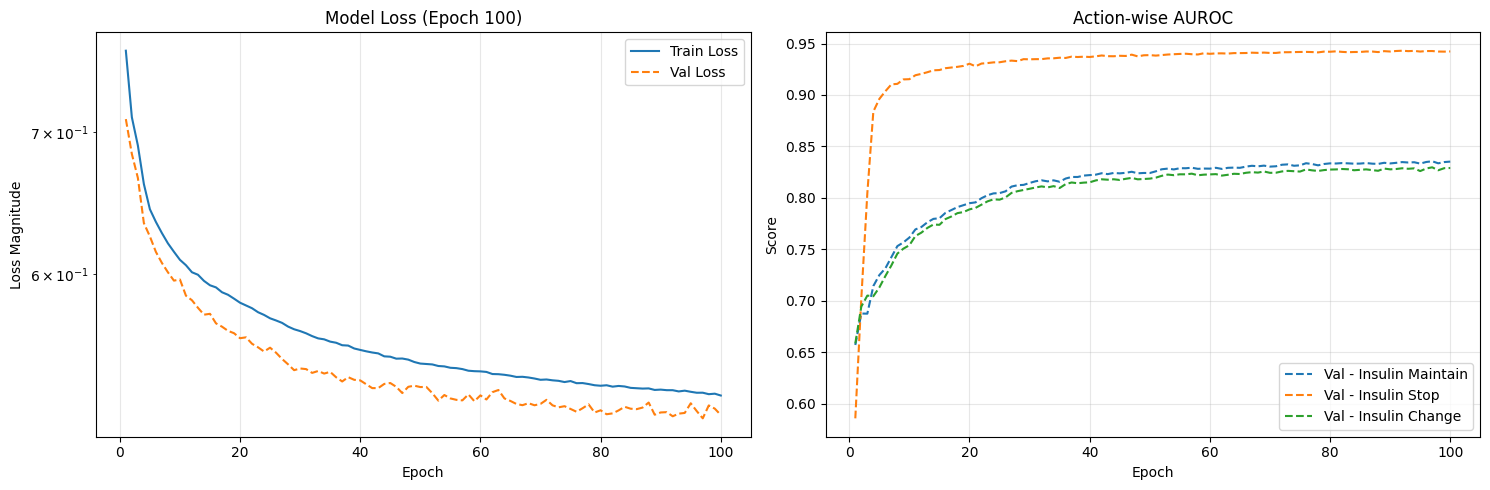

In [11]:
n_train = len(train_dataloader)
n_val = len(val_dataloader)

# Instantiate model class + optimizer
policy_model = CNNLSTMModel(n_features=140, out_dim=3).to(DEVICE)
if DEVICE == 'cuda':
    policy_model = torch.compile(policy_model)
optimizer = torch.optim.Adam(policy_model.parameters(), lr=1e-4)

# Specify our logging variables
available_actions = ["Insulin Maintain", "Insulin Stop", "Insulin Change"]
train_auroc_metrics = {action: BinaryAUROC() for action in available_actions}
val_auroc_metrics = {action: BinaryAUROC() for action in available_actions}

train_auroc_history = {action: [] for action in available_actions}
val_auroc_history = {action: [] for action in available_actions}
train_loss_history = []
val_loss_history = []
epoch_iters = []

# Specify epochs
n_epochs = 100
batch_size = 512

# Start training loop
for epoch in range(n_epochs):
    epoch_iters.append(epoch + 1)

    policy_model.train()
    train_loss_sum = torch.tensor(0.0, device=DEVICE)

    with tqdm(total=n_train, mininterval=5, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", leave=False) as pbar:
        for batch in train_dataloader:
            # ==========================
            #      TRAINING PHASE
            # ==========================

            target_actions = torch.argmax(batch.actions, -1)
    
            # Forward pass & Loss
            y_pred = policy_model(batch.states)
            loss = F.cross_entropy(y_pred, target_actions)
            train_loss_sum += loss.detach().clone()
    
            # Optimisation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            # Update metrics
            y_prob = F.softmax(y_pred, dim=-1)
            for i, action in enumerate(available_actions):
                binary_target = (target_actions == i).long()
                train_auroc_metrics[action].update(y_prob[:, i], binary_target)

            pbar.update(1)

    # Compute epoch-level train metrics
    train_loss_history.append(train_loss_sum.cpu().item() / n_train)

    for action in available_actions:
        score = train_auroc_metrics[action].compute().item()
        train_auroc_history[action].append(score)
        train_auroc_metrics[action].reset() # Clear metric state for next epoch

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    policy_model.eval()
    val_loss_sum = torch.tensor(0.0, device=DEVICE)

    with tqdm(total=n_val, mininterval=5, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", leave=False) as pbar:
        for batch in val_dataloader:

            target_actions = torch.argmax(batch.actions, -1)
    
            # Forward pass & Loss
            y_pred = policy_model(batch.states)
            loss = F.cross_entropy(y_pred, target_actions)
            val_loss_sum += loss.detach().clone()
    
            # Update metrics
            y_prob = F.softmax(y_pred, dim=-1)
            for i, action in enumerate(available_actions):
                binary_target = (target_actions == i).long()
                val_auroc_metrics[action].update(y_prob[:, i], binary_target)

            pbar.update(1)

    # Compute epoch-level validation metrics
    final_val_loss = val_loss_sum.cpu().item() / n_val
    val_loss_history.append(final_val_loss)     

    for action in available_actions:
        score = val_auroc_metrics[action].compute().item()
        val_auroc_history[action].append(score)
        val_auroc_metrics[action].reset() # Clear metric state for next epoch

    # Combine metrics into dictionaries for the plotting function
    combined_losses = {
        'Train Loss': train_loss_history,
        'Val Loss': val_loss_history
    }
    
    # Package ONLY the validation AUROCs
    val_only_aurocs = {}
    for action in available_actions:
        val_only_aurocs[f'Val - {action}'] = val_auroc_history[action]

    # Single call to update_plots per epoch
    update_plots(epoch + 1, epoch_iters, combined_losses, val_only_aurocs)

In [12]:
print('Final validation AUROC scores:')
for key in val_only_aurocs.keys():
    print(f'{key}: {val_only_aurocs[key][-1]: .4f}')

Final validation AUROC scores:
Val - Insulin Maintain:  0.8353
Val - Insulin Stop:  0.9423
Val - Insulin Change:  0.8291


If you don't have access to a GPU, over time you would get a training log like the following:

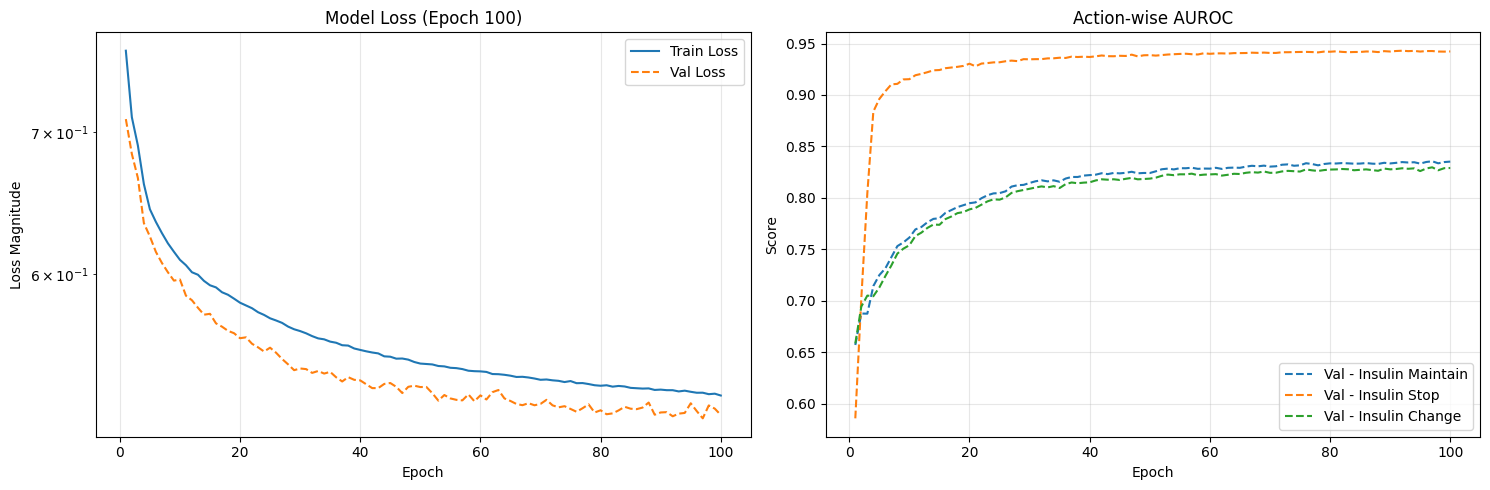

## Off-Policy Evaluation with Fitted Q-Evaluation

For off-policy evaluation, given we are using continuous states, we recommend using a model-based technique such as Fitted Q-Evaluation (FQE)$^1$. To train our FQE model, we need to define a reward that our policy is trying to optimise - we will use the Magni risk index$^2$ to give a reward for the next glucose.

In our `FQEDataset`, we will need the `states`, `actions`, `rewards`, `next states`, and `dones` tensors. We will also need `time_until_next_bm` (from `infos`) to discount time correctly. Lastly, we will also collect `next_actions` so we can train a comparator FQE model on the dataset's own behaviour.

$^1$ Le, Hoang, Cameron Voloshin, and Yisong Yue. "Batch policy learning under constraints." International Conference on Machine Learning. PMLR, 2019
$^2$ Magni, Lalo, et al. "Model predictive control of type 1 diabetes: an in silico trial." (2007): 804-812

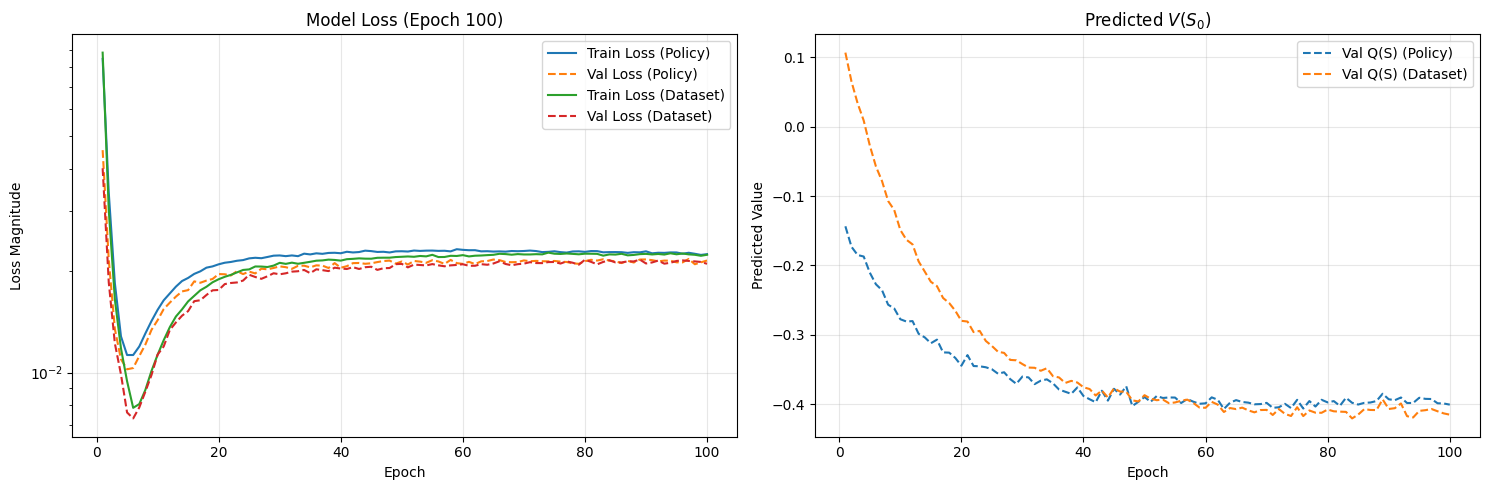

In [13]:
# Train a Fitted Q-evaluation model for Off-Policy Evaluation
# We train two FQE models against...
# 1) the Behavioural Cloning model we just trained
# 2) the dataset's own behaviour

train_dataset = FQEDataset(segment_dir='./data/insulin4rl/train', device=DEVICE)
val_dataset = FQEDataset(segment_dir='./data/insulin4rl/val', device=DEVICE)

train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)

policy_model.eval() # Ensure the BC policy is in evaluation mode

# =======================================================================
# INITIALIZE BOTH Q-MODELS
# =======================================================================
# 1. Q-Model for evaluating the Learned Policy (Off-Policy / FQE)
q_policy = CNNLSTMModel(n_features=140, out_dim=3).to(DEVICE)
q_policy_target = copy.deepcopy(q_policy).to(DEVICE)

# 2. Q-Model for evaluating the Dataset's empirical behaviour
q_dataset = CNNLSTMModel(n_features=140, out_dim=3).to(DEVICE)
q_dataset_target = copy.deepcopy(q_dataset).to(DEVICE)

all_models = q_policy, q_policy_target, q_dataset, q_dataset_target
q_policy, q_policy_target, q_dataset, q_dataset_target = map(torch.compile, all_models)

q_optimizer = torch.optim.Adam(
    list(q_policy.parameters()) + list(q_dataset.parameters()), lr=1e-4
)

gamma_base = 0.999    # Base discount factor (per minute)
polyak = 0.001

# Specify our logging variables
train_loss_policy_history = []
val_loss_policy_history = []
train_loss_dataset_history = []
val_loss_dataset_history = []

# Specify Q-value tracking variables
val_q_policy_history = []
val_q_dataset_history = []

epoch_iters = []

# Specify total epochs
n_epochs = 100

# Specify our reward function
def risk_score_calc(x):
    return 0.1 * (3.35506 * (torch.log(x * 18.0182 + 1e-6)**0.8353 - 3.7932))**2

# Start training loop
for epoch in range(n_epochs):
    epoch_iters.append(epoch + 1)

    q_policy.train()
    q_dataset.train()
    
    train_loss_policy_sum = 0.0
    train_loss_dataset_sum = 0.0

    with tqdm(total=n_train, mininterval=5, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", leave=False) as pbar:
        for batch in train_dataloader:

            # ==========================
            #      TRAINING PHASE
            # ==========================
                
            # Extract target actions taken in the current state
            target_actions = torch.argmax(batch.actions, -1)
            
            # Extract the actions actually taken in the next state by the dataset behavior policy
            dataset_next_actions = torch.argmax(batch.next_actions, -1)
        
            # =======================================================================
            # SMDP REWARD & DISCOUNT COMPUTATION
            # =======================================================================
            next_bm = batch.reward_markers
            time_to_next_bm = batch.infos['time_until_next_bm']
            
            # Calculate Magni Risk Score and assign as negative reward
            risk_score = risk_score_calc(next_bm)
            risk_score = torch.nan_to_num(risk_score, nan=0.0)
            glucose_reward = -risk_score 
        
            # SMDP Discounting using time_until_next_bm (minutes)
            dt = torch.nan_to_num(time_to_next_bm, nan=0.0)
            discounts = torch.pow(gamma_base, dt) * (1.0 - batch.dones.float())
        
            # =======================================================================
            # Q-TARGET COMPUTATION FOR BOTH MODELS
            # =======================================================================
            with torch.no_grad():
                # For terminal states, make sure the all-NaN next state is set to zero
                next_states = torch.where(batch.dones.view(-1, 1, 1), torch.zeros_like(batch.next_states), batch.next_states)
                
                # --- Target 1: Policy Model (FQE) ---
                policy_logits = policy_model(next_states)
                policy_next_actions = torch.argmax(policy_logits, dim=-1)
                
                next_q_policy = q_policy_target(next_states).gather(-1, policy_next_actions.unsqueeze(-1))
                q_policy_targets = glucose_reward + discounts * next_q_policy
                
                # --- Target 2: Dataset Behavior (SARSA) ---
                next_q_dataset = q_dataset_target(next_states).gather(-1, dataset_next_actions.unsqueeze(-1))
                q_dataset_targets = glucose_reward + discounts * next_q_dataset
                
            # =======================================================================
            # LOSS COMPUTATION & BACKPROPAGATION
            # =======================================================================
            q_policy_pred = q_policy(batch.states).gather(-1, target_actions.unsqueeze(-1))
            q_dataset_pred = q_dataset(batch.states).gather(-1, target_actions.unsqueeze(-1))
            
            q_policy_loss = F.mse_loss(q_policy_pred, q_policy_targets)
            q_dataset_loss = F.mse_loss(q_dataset_pred, q_dataset_targets)
    
            all_losses = q_policy_loss + q_dataset_loss
            
            # Optimize Models
            q_optimizer.zero_grad()
            all_losses.backward()
            q_optimizer.step()
        
            # =======================================================================
            # POLYAK TARGET UPDATES
            # =======================================================================
            q_policy.soft_update(q_policy_target, polyak)
            q_dataset.soft_update(q_dataset_target, polyak)
    
            # Update logging sums
            train_loss_policy_sum += q_policy_loss.item()
            train_loss_dataset_sum += q_dataset_loss.item()

            pbar.update(1)

    # Compute epoch-level train metrics
    train_loss_policy_history.append(train_loss_policy_sum / n_train)
    train_loss_dataset_history.append(train_loss_dataset_sum / n_train)

    # ==========================
    #      VALIDATION PHASE
    # ==========================
    q_policy.eval()
    q_dataset.eval()
    
    val_loss_policy_sum = 0.0
    val_loss_dataset_sum = 0.0
    
    val_q_policy_sum = 0.0
    val_q_dataset_sum = 0.0

    with tqdm(total=n_val, mininterval=5, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", leave=False) as pbar:
        for batch in val_dataloader:
        
            with torch.no_grad():
                target_actions = torch.argmax(batch.actions, -1)
                dataset_next_actions = torch.argmax(batch.next_actions, -1)
            
                # Rewards & Discounts
                next_bm = batch.reward_markers
                time_to_next_bm = batch.infos['time_until_next_bm']
                
                risk_score = risk_score_calc(next_bm)
                risk_score = torch.nan_to_num(risk_score, nan=0.0)
                glucose_reward = -risk_score 
            
                dt = torch.nan_to_num(time_to_next_bm, nan=0.0)
                discounts = torch.pow(gamma_base, dt) * (1.0 - batch.dones.float())
            
                # Targets
                next_states = torch.where(batch.dones.view(-1, 1, 1), torch.zeros_like(batch.next_states), batch.next_states)
                
                # --- Target 1: Policy Model (FQE) ---
                policy_logits = policy_model(next_states)
                policy_next_actions = torch.argmax(policy_logits, dim=-1)
                
                next_q_policy = q_policy_target(next_states).gather(-1, policy_next_actions.unsqueeze(-1))
                q_policy_targets = glucose_reward + discounts * next_q_policy
                
                # --- Target 2: Dataset Behavior (SARSA) ---
                next_q_dataset = q_dataset_target(next_states).gather(-1, dataset_next_actions.unsqueeze(-1))
                q_dataset_targets = glucose_reward + discounts * next_q_dataset
                
                # Forward Pass & Loss
                q_policy_pred = q_policy(batch.states).gather(-1, target_actions.unsqueeze(-1))
                q_dataset_pred = q_dataset(batch.states).gather(-1, target_actions.unsqueeze(-1))
                
                q_policy_loss = F.mse_loss(q_policy_pred, q_policy_targets)
                q_dataset_loss = F.mse_loss(q_dataset_pred, q_dataset_targets)
        
                # =======================================================================
                # CALCULATE Q(S_0) FOR PLOTTING
                # =======================================================================
                # 1. Get the policy's recommended action for the current state (S_0 proxy)
                current_policy_logits = policy_model(batch.states)
                current_policy_actions = torch.argmax(current_policy_logits, dim=-1)
                
                # 2. Evaluate the learned policy's Q-value using its own recommended action
                current_q_policy = q_policy(batch.states).gather(-1, current_policy_actions.unsqueeze(-1))
                
                # 3. Evaluate the dataset's Q-value using the dataset actions (for comparison)
                current_q_dataset = q_dataset(batch.states).gather(-1, target_actions.unsqueeze(-1))
        
                # Update logging sums
                val_loss_policy_sum += q_policy_loss.item()
                val_loss_dataset_sum += q_dataset_loss.item()
                
                val_q_policy_sum += current_q_policy.mean().item()
                val_q_dataset_sum += current_q_dataset.mean().item()

            pbar.update(1)

    # Compute epoch-level validation metrics
    val_loss_policy_history.append(val_loss_policy_sum / n_val)
    val_loss_dataset_history.append(val_loss_dataset_sum / n_val)
    
    val_q_policy_history.append(val_q_policy_sum / n_val)
    val_q_dataset_history.append(val_q_dataset_sum / n_val)

    # Combine metrics into dictionaries for the plotting function
    combined_losses = {
        'Train Loss (Policy)': train_loss_policy_history,
        'Val Loss (Policy)': val_loss_policy_history,
        'Train Loss (Dataset)': train_loss_dataset_history,
        'Val Loss (Dataset)': val_loss_dataset_history
    }
    
    combined_q_values = {
        'Val Q(S) (Policy)': val_q_policy_history,
        'Val Q(S) (Dataset)': val_q_dataset_history
    }
    
    # Pass combined_q_values to the v_s0 parameter specifically
    update_plots(epoch + 1, epoch_iters, combined_losses, v_s0=combined_q_values)

If you don't have access to a GPU, over time you would get a training log like the following.

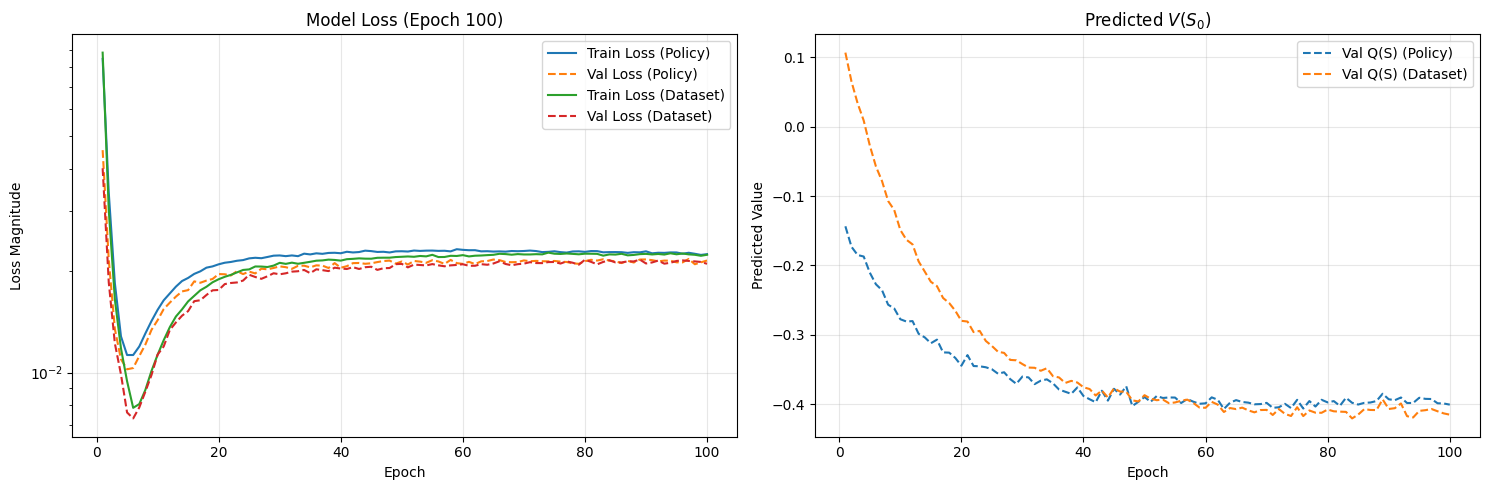

The FQE results suggest that there is very little difference between the discounted return from the dataset behaviour versus our policy behaviour.

Bear in mind that these are relatively basic demonstrations. We obviously have not accounted for how the insulin might be changed (e.g., increased vs decreased, and by how much). In practice, you would train using more complex offline RL algorithms for a broader action space, and then validate appropriately using the validation/test segments of the dataset.

<span style="font-size: 18px;">Have fun!</span>